# Etape 1 - Importation des librairies et chargement des fichiers

# Etape 1 - Importation des librairies et chargement du fichier nettoyé

### 1.1 - Importation des librairies

In [ ]:
#Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import itertools
from scipy.stats import chi2_contingency
from scipy.stats import norm
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import f_oneway
from scipy.stats import kruskal
from datetime import datetime
from scipy.stats import levene
from statsmodels.stats.oneway import anova_oneway
from scipy.stats import mannwhitneyu



In [ ]:
#permet d'aller prendre les fichiers directement dans mon drive
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/My Drive/Colab Notebooks/Lapage/

Mounted at /content/drive/
/content/drive/My Drive/Colab Notebooks/Lapage


In [ ]:
#afficher toutes les colonnes de mon dataframe
pd.set_option('display.max_columns', None)

### 1.2 - Chargements du fichier

In [ ]:
#Importation du fichier df_clean.csv
df_clean = pd.read_csv("df_clean.csv", sep=",")

# Etape 2 - Analyse exploratoire du fichier

### 2.1 - Analyse exploratoire du fichier df_clean.csv

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_clean.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_clean.shape[1]))

Le tableau comporte 640734 observation(s) ou article(s)
Le tableau comporte 9 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print("Le nombre de colonnes est de : ",df_clean.shape[1],"\n")
#La nature des données dans chacune des colonnes
print("Nature des données pour chaques colonnes :\n", df_clean.dtypes,"\n")
#Le nombre de valeurs présentes dans chacune des colonnes
print("Nombre de valeurs par colonnes :\n", df_clean.count())

Le nombre de colonnes est de :  9 

Nature des données pour chaques colonnes :
 id_prod        object
date           object
session_id     object
client_id      object
sex            object
birth           int64
price         float64
categ           int64
mois           object
dtype: object 

Nombre de valeurs par colonnes :
 id_prod       640734
date          640734
session_id    640734
client_id     640734
sex           640734
birth         640734
price         640734
categ         640734
mois          640734
dtype: int64


In [ ]:
#Afficher les 5 premières lignes de la table
df_clean.head()

,id_prod,date,session_id,client_id,sex,birth,price,categ,mois
0,0_1259,2021-03-01,s_1,c_329,f,1967,11.99,0,2021-03
1,0_1390,2021-03-01,s_2,c_664,m,1960,19.37,0,2021-03
2,0_1352,2021-03-01,s_3,c_580,m,1988,4.50,0,2021-03
3,0_1458,2021-03-01,s_4,c_7912,f,1989,6.55,0,2021-03
4,0_1358,2021-03-01,s_5,c_2033,f,1956,16.49,0,2021-03


# Etape 3 - Analyse des corrélations

### Etape 3.1 - Corrélation genre d'un client et catégories de livres achetés

In [ ]:
# Prep Catégorie la plus chère
df_client_categ = (
    df_clean
    .groupby(['client_id', 'sex', 'birth', 'categ'])['price']
    .sum()
    .reset_index()
    .sort_values(['client_id', 'price'], ascending=[True, False])
    .drop_duplicates('client_id') #permet de conserver seulement la catégorie la plus acheté par chaque client
    .rename(columns={'categ': 'categ_dominante_CA'})
)
display(df_client_categ)

,client_id,sex,birth,categ_dominante_CA,price
0,c_1,m,1955,0,360.15
4,c_10,m,1956,1,809.77
8,c_100,m,1992,2,138.53
10,c_1000,f,1966,1,1905.03
11,c_1001,m,1982,0,907.73
...,...,...,...,...,...
19928,c_995,m,1955,0,125.67
19931,c_996,f,1970,1,1151.57
19934,c_997,f,1994,2,810.98
19937,c_998,m,2001,2,2403.41


In [ ]:
# Prep catégorie la plus achetée
#df_client_categ = (
#    df_clean
#    .groupby(['client_id', 'sex', 'birth', 'categ'])['price'].count()
#    .reset_index()
#    .sort_values(['client_id', 'price'], ascending=[True, False])
#    .drop_duplicates('client_id') #permet de conserver seulement la catégorie la plus acheté par chaque client
#    .rename(columns={'categ': 'categ_dominante_CA'})
#)
#display(df_client_categ)

In [ ]:
# Préparation des données
display(df_client_categ)
contingency_table = pd.crosstab(df_client_categ['sex'], df_client_categ['categ_dominante_CA'])
print(contingency_table)

,client_id,sex,birth,categ_dominante_CA,price
0,c_1,m,1955,0,360.15
4,c_10,m,1956,1,809.77
8,c_100,m,1992,2,138.53
10,c_1000,f,1966,1,1905.03
11,c_1001,m,1982,0,907.73
...,...,...,...,...,...
19928,c_995,m,1955,0,125.67
19931,c_996,f,1970,1,1151.57
19934,c_997,f,1994,2,810.98
19937,c_998,m,2001,2,2403.41


categ_dominante_CA     0     1     2
sex                                 
f                   1570  1861  1047
m                   1504  1645   969


<Axes: xlabel='sex', ylabel='nombre'>

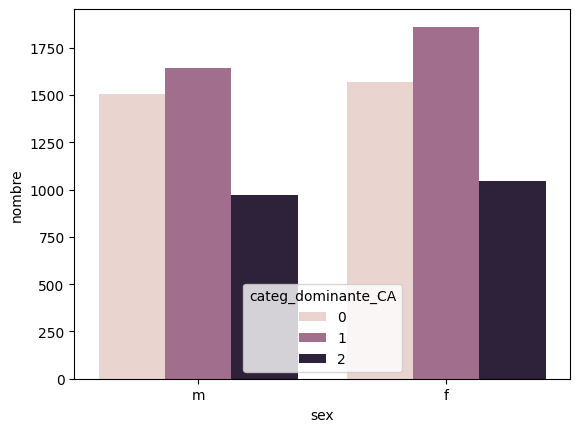

In [ ]:
#Création d'un histogramme
df_client_categ["nombre"] = 1
sns.barplot(data=df_client_categ, x="sex", y="nombre", hue="categ_dominante_CA", estimator="sum")

<Axes: xlabel='categ_dominante_CA', ylabel='sex'>

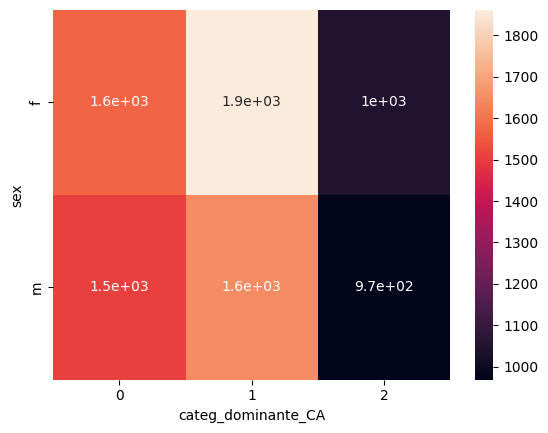

In [ ]:
#Création d'une heatmap
sns.heatmap(contingency_table, annot=True)

In [ ]:
# Test de chi2
# H0 Il n’existe pas d’association entre le genre du client et la catégorie de livre achetée.
# H1 Il existe une association entre le genre du client et la catégorie de livre achetée.

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Statistique Chi-2: {chi2_stat}")
print(f"Valeur p: {p_value}")
print(f"Degrés de liberté: {dof}")
print("Fréquences attendues:")
print(expected)

if p_value < 0.05:
    print("\nOn rejette H0")
else:
    print("On ne peut rejeter H0")

# Dans les deux cas H0 ne peut être rejetée

Statistique Chi-2: 2.6702798258632847
Valeur p: 0.2631213587998382
Degrés de liberté: 2
Fréquences attendues:
[[1601.36947417 1826.41554211 1050.21498371]
 [1472.63052583 1679.58445789  965.78501629]]
On ne peut rejeter H0


### Etape 3.2 - Corrélation entre l'âge du client et le montant des achats

In [ ]:
#prep
df_client = (df_clean.groupby(['client_id', 'sex', 'birth'])['price'].sum().reset_index().rename(columns={'price': 'total_achats'}))
display(df_client)

,client_id,sex,birth,total_achats
0,c_1,m,1955,629.02
1,c_10,m,1956,1353.60
2,c_100,m,1992,254.85
3,c_1000,f,1966,2291.88
4,c_1001,m,1982,1823.85
...,...,...,...,...
8591,c_995,m,1955,189.41
8592,c_996,f,1970,1637.34
8593,c_997,f,1994,1490.01
8594,c_998,m,2001,2822.22


In [ ]:
# Calcul de l'âge
current_year = datetime.now().year
df_client['age'] = current_year  - df_client['birth']
display(df_client)

#combien de client distinct
print("Nombre de client distinct : ", df_client['client_id'].nunique())

,client_id,sex,birth,total_achats,age
0,c_1,m,1955,629.02,71
1,c_10,m,1956,1353.60,70
2,c_100,m,1992,254.85,34
3,c_1000,f,1966,2291.88,60
4,c_1001,m,1982,1823.85,44
...,...,...,...,...,...
8591,c_995,m,1955,189.41,71
8592,c_996,f,1970,1637.34,56
8593,c_997,f,1994,1490.01,32
8594,c_998,m,2001,2822.22,25


Nombre de client distinct :  8596


Moyenne de l'âge : 47.739646347138205
Écart type de l'âge : 16.91054150589733


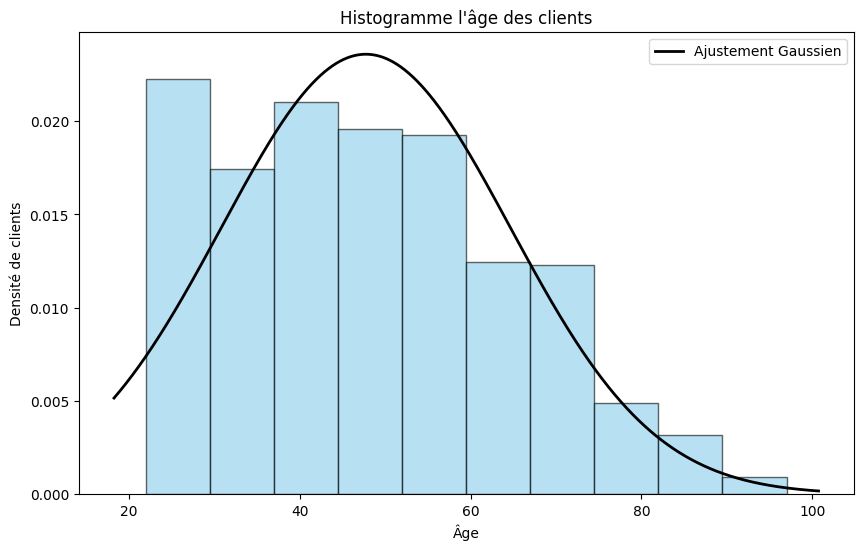

In [ ]:
# Préparation des données âge

# Extraire la colonne 'age'
age = df_client['age'].dropna()

# Calculer la moyenne et l'écart type
mean_age = age.mean()
std_age = age.std()

# Afficher les valeurs calculées
print(f"Moyenne de l'âge : {mean_age}")
print(f"Écart type de l'âge : {std_age}")

# Tracer l'histogramme avec une courbe gaussienne
plt.figure(figsize=(10, 6))

# Histogramme

plt.hist(age, bins=10, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Ajustement gaussien
mu, std = norm.fit(age)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, age.count())
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
plt.plot(x, p, 'k', linewidth=2, label='Ajustement Gaussien')

# Ajouter les titres et légendes en français
plt.title('Histogramme l\'âge des clients')
plt.xlabel('Âge')
plt.ylabel('Densité de clients')
plt.legend()

# Afficher le graphique
plt.show()

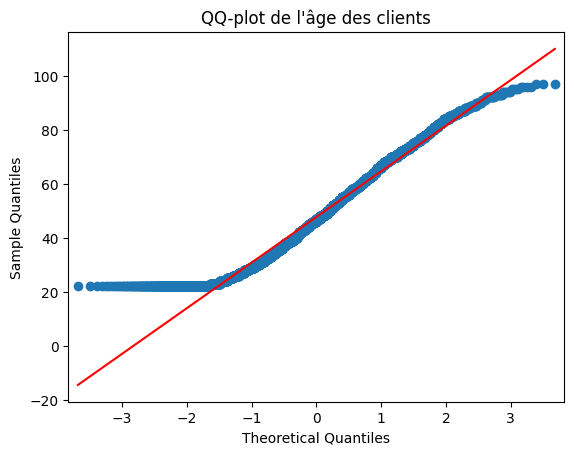

In [ ]:
#Faire graphique qqplot ou kstest
sm.qqplot(df_client['age'], line='s')
plt.title("QQ-plot de l'âge des clients")
plt.show()

#Le QQ-plot de l’âge montre une bonne adéquation à la normalité au centre de la distribution. Les écarts observés dans les queues sont dus aux bornes naturelles de la variable âge.
#Compte tenu de la taille de l’échantillon, l’hypothèse de normalité est considérée comme acceptable pour l’utilisation de tests paramétriques.

Moyenne du montant d'achat : 1296.3433003722662
Écart type du montant d'achat : 958.4045435066197


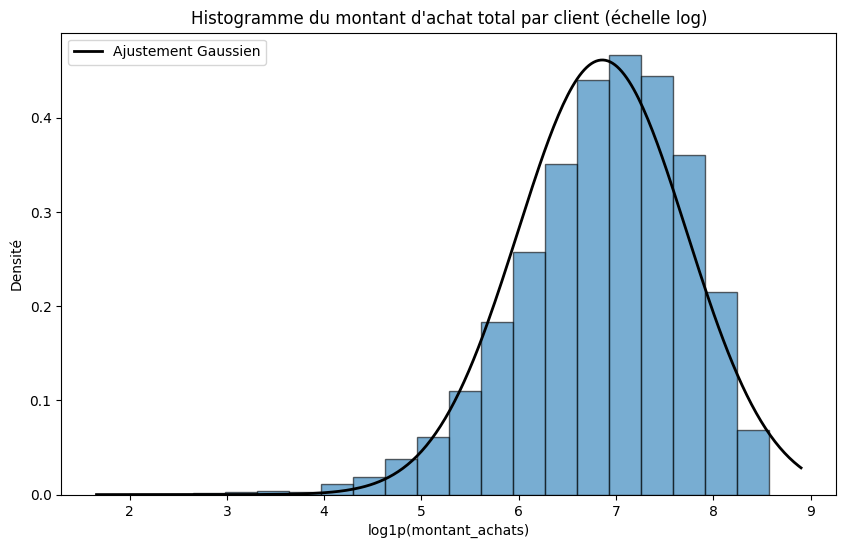

In [ ]:
# Extraire la colonne 'montant_achats'
montant = df_client['total_achats'].dropna()
montant_log = np.log1p(montant)  # log(1+x) -> réduit l'asymétrie sur la droite du aux valeurs extrêmes

# Calculer la moyenne et l'écart type
mean_montant = montant.mean()
std_montant = montant.std()

# Afficher les valeurs calculées
print(f"Moyenne du montant d'achat : {mean_montant}")
print(f"Écart type du montant d'achat : {std_montant}")

# Tracer l'histogramme avec une courbe gaussienne
plt.figure(figsize=(10, 6))

# Histogramme

plt.hist(montant_log, bins=20, density=True, edgecolor='black', alpha=0.6)

# Ajustement gaussien
mu, sigma = norm.fit(montant_log)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 300)
p = norm.pdf(x, mu, sigma)

# Tracer la courbe gaussienne
plt.plot(x, p, 'k', linewidth=2, label="Ajustement Gaussien")

# Ajouter les titres et légendes en français
plt.title("Histogramme du montant d'achat total par client (échelle log)")
plt.xlabel("log1p(montant_achats)")
plt.ylabel("Densité")
plt.legend()

# Afficher le graphique
plt.show()

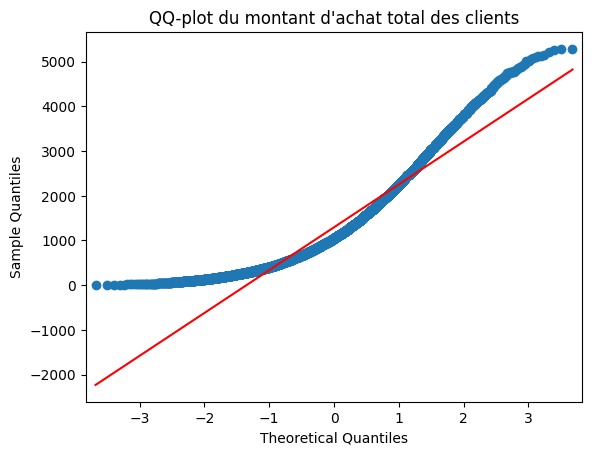

In [ ]:
#Faire graphique qqplot
sm.qqplot(df_client['total_achats'], line='s')
plt.title("QQ-plot du montant d'achat total des clients")
plt.show()

Coefficient de corrélation de Spearman: -0.18453828119895269
Valeur p: 1.0208987071136737e-66


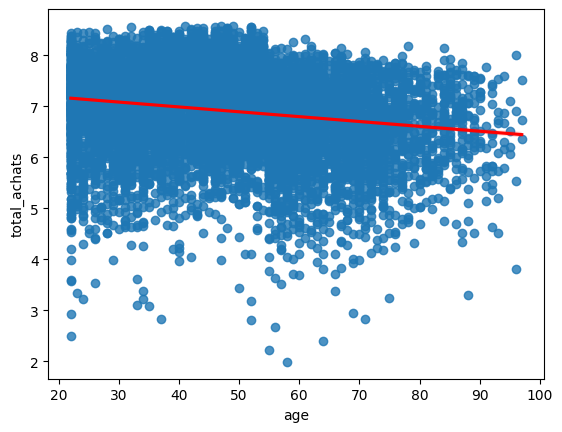

In [ ]:
# test de Spearman

# 1) Transformation log
df_client['total_achats'] = np.log1p(df_client['total_achats'])

# 2) Visualisation correcte
sns.regplot(data=df_client,x='age',y='total_achats',robust=True,line_kws=dict(color="r"))

# 3) Pearson valide
spearman_corr, spearman_p_value = spearmanr(df_client['age'], df_client['total_achats'])

print(f"Coefficient de corrélation de Spearman: {spearman_corr}")
print(f"Valeur p: {spearman_p_value}")

#Il semble y avoir une légère corrélation négative entre l'âge et le montant dépensé.

### Etape 3.3 - Corrélation entre l'âge du client et la fréquence d'achat

In [ ]:
# Calcul de l'âge
current_year = datetime.now().year
df_clean['age'] = current_year  - df_clean['birth']

# Préparation des données frequence d'achat
display(df_clean)

df_clean['date'] = pd.to_datetime(df_clean['date'])

df_freq = (df_clean.groupby('client_id').agg(age=('age', 'first'),nb_sessions=('session_id', 'nunique'),debut=('date', 'min'),fin=('date', 'max')).reset_index())

df_freq['duree_jours'] = (df_freq['fin'] - df_freq['debut']).dt.days + 1
df_freq = df_freq[df_freq['duree_jours'].astype(int) > 1] #on se sépare des clients qui n'ont acheté que sur une journée car pas de freq possible
df_freq['freq_achat_annuel'] = df_freq['nb_sessions'] / (df_freq['duree_jours'] / 365)

display(df_freq)

display(df_freq.sort_values('duree_jours').head())

,id_prod,date,session_id,client_id,sex,birth,price,categ,mois,age
0,0_1259,2021-03-01,s_1,c_329,f,1967,11.99,0,2021-03,59
1,0_1390,2021-03-01,s_2,c_664,m,1960,19.37,0,2021-03,66
2,0_1352,2021-03-01,s_3,c_580,m,1988,4.50,0,2021-03,38
3,0_1458,2021-03-01,s_4,c_7912,f,1989,6.55,0,2021-03,37
4,0_1358,2021-03-01,s_5,c_2033,f,1956,16.49,0,2021-03,70
...,...,...,...,...,...,...,...,...,...,...
640729,1_508,2023-02-28,s_348444,c_3573,f,1996,21.92,1,2023-02,30
640730,2_37,2023-02-28,s_348445,c_50,f,1994,48.99,2,2023-02,32
640731,1_695,2023-02-28,s_348446,c_488,f,1985,26.99,1,2023-02,41
640732,0_1547,2023-02-28,s_348447,c_4848,m,1953,8.99,0,2023-02,73


,client_id,age,nb_sessions,debut,fin,duree_jours,freq_achat_annuel
0,c_1,71,34,2021-06-11,2023-01-15,584,21.250000
1,c_10,70,34,2021-03-21,2023-01-27,678,18.303835
2,c_100,34,5,2021-04-20,2022-09-20,519,3.516378
3,c_1000,60,94,2021-03-13,2023-01-24,683,50.234261
4,c_1001,44,47,2021-03-07,2023-02-23,719,23.859527
...,...,...,...,...,...,...,...
8591,c_995,71,9,2021-04-08,2022-11-21,593,5.539629
8592,c_996,56,80,2021-03-01,2023-02-21,723,40.387275
8593,c_997,32,24,2021-04-30,2023-02-05,647,13.539413
8594,c_998,25,24,2021-03-18,2023-02-22,707,12.390382


,client_id,age,nb_sessions,debut,fin,duree_jours,freq_achat_annuel
5595,c_6049,62,2,2021-05-03,2021-05-14,12,60.833333
4084,c_4686,74,2,2021-03-17,2021-04-07,22,33.181818
6735,c_7079,57,2,2021-12-24,2022-01-16,24,30.416667
7124,c_7429,34,2,2021-10-16,2021-11-12,28,26.071429
1715,c_2544,22,2,2021-06-24,2021-07-24,31,23.548387


Moyenne de la frequence d'achat : 19.923236806200435
Écart type de la frequence d'achat : 15.357132413463525


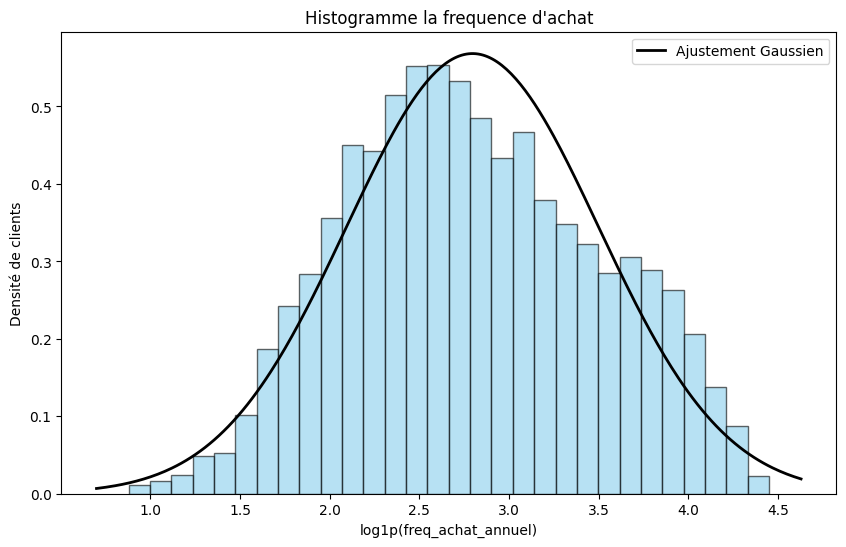

In [ ]:
# test distribution

# Extraire la colonne 'freq_achat'
freq = df_freq['freq_achat_annuel'].dropna()
freq_log = np.log1p(freq) # log(1+x) -> réduit l'asymétrie sur la droite du aux valeurs extrêmes

# Calculer la moyenne et l'écart type
mean_freq_achat = freq.mean()
std_freq_achat = freq.std()

# Afficher les valeurs calculées
print(f"Moyenne de la frequence d'achat : {mean_freq_achat}")
print(f"Écart type de la frequence d'achat : {std_freq_achat}")

# Tracer l'histogramme avec une courbe gaussienne
plt.figure(figsize=(10, 6))

# Histogramme

plt.hist(freq_log, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Ajustement gaussien
mu, std = norm.fit(freq_log)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 300)
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
plt.plot(x, p, 'k', linewidth=2, label='Ajustement Gaussien')

# Ajouter les titres et légendes en français
plt.title('Histogramme la frequence d\'achat')
plt.xlabel('log1p(freq_achat_annuel)')
plt.ylabel('Densité de clients')
plt.legend()

# Afficher le graphique
plt.show()

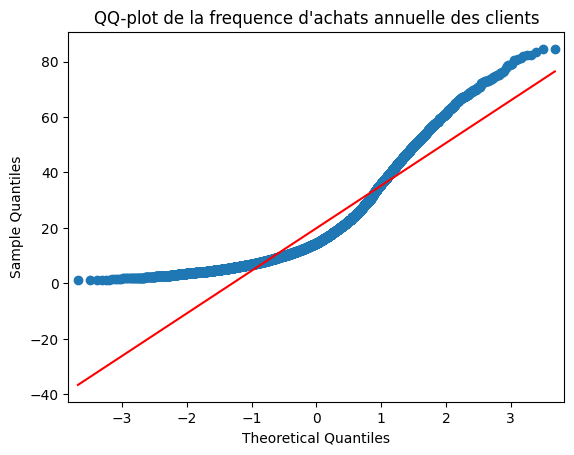

In [ ]:
#Faire graphique qqplot
sm.qqplot(df_freq['freq_achat_annuel'], line='s')
plt.title("QQ-plot de la frequence d'achats annuelle des clients")
plt.show()

Coefficient de corrélation de Spearman: 0.21068486112576418
Valeur p: 1.1956380851596397e-86


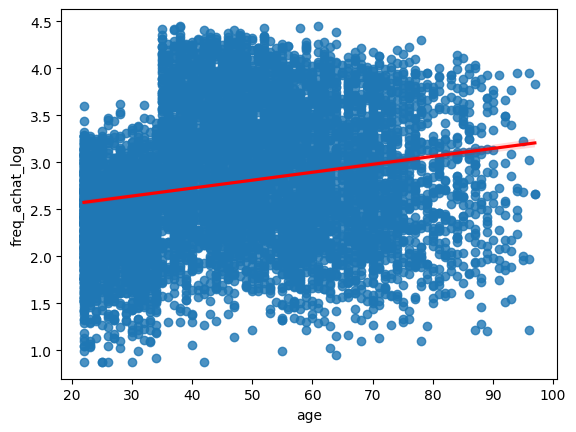

In [ ]:
# test de Spearman

# 1) Sélection colonnes
freq_achat = df_freq[['age', 'freq_achat_annuel']].dropna()

# 2) Transformation log
freq_achat['freq_achat_log'] = np.log1p(freq_achat['freq_achat_annuel'])

# 3) Visualisation correcte
sns.regplot(data=freq_achat,x='age',y='freq_achat_log',robust=True,line_kws=dict(color="r"))

# 4) Pearson valide
correlation, p_value = spearmanr(freq_achat['age'], freq_achat['freq_achat_log'])

print(f"Coefficient de corrélation de Spearman: {correlation}")
print(f"Valeur p: {p_value}")

# Il existe une corrélation positive faible mais statistiquement significative entre l’âge et la fréquence d’achat annuelle (après transformation logarithmique)

### Etape 3.4 - Corrélation entre l'âge du client et la taille du panier

In [ ]:
# Préparation des données sur la taille du panier
display(df_clean)

df_taille_panier = (df_clean.groupby('client_id').agg(age=('age', 'first'),total_CA=('price', 'sum'),nb_sessions=('session_id', 'nunique')).reset_index())

df_taille_panier['taille_panier_moyenne'] = (df_taille_panier['total_CA'] / df_taille_panier['nb_sessions']).round(0).astype(int)

display(df_taille_panier)

,id_prod,date,session_id,client_id,sex,birth,price,categ,mois,age
0,0_1259,2021-03-01,s_1,c_329,f,1967,11.99,0,2021-03,59
1,0_1390,2021-03-01,s_2,c_664,m,1960,19.37,0,2021-03,66
2,0_1352,2021-03-01,s_3,c_580,m,1988,4.50,0,2021-03,38
3,0_1458,2021-03-01,s_4,c_7912,f,1989,6.55,0,2021-03,37
4,0_1358,2021-03-01,s_5,c_2033,f,1956,16.49,0,2021-03,70
...,...,...,...,...,...,...,...,...,...,...
640729,1_508,2023-02-28,s_348444,c_3573,f,1996,21.92,1,2023-02,30
640730,2_37,2023-02-28,s_348445,c_50,f,1994,48.99,2,2023-02,32
640731,1_695,2023-02-28,s_348446,c_488,f,1985,26.99,1,2023-02,41
640732,0_1547,2023-02-28,s_348447,c_4848,m,1953,8.99,0,2023-02,73


,client_id,age,total_CA,nb_sessions,taille_panier_moyenne
0,c_1,71,629.02,34,19
1,c_10,70,1353.60,34,40
2,c_100,34,254.85,5,51
3,c_1000,60,2291.88,94,24
4,c_1001,44,1823.85,47,39
...,...,...,...,...,...
8591,c_995,71,189.41,9,21
8592,c_996,56,1637.34,80,20
8593,c_997,32,1490.01,24,62
8594,c_998,25,2822.22,24,118


Moyenne du panier : 40.40414146114472
Écart type du panier moyen : 22.76445902783581


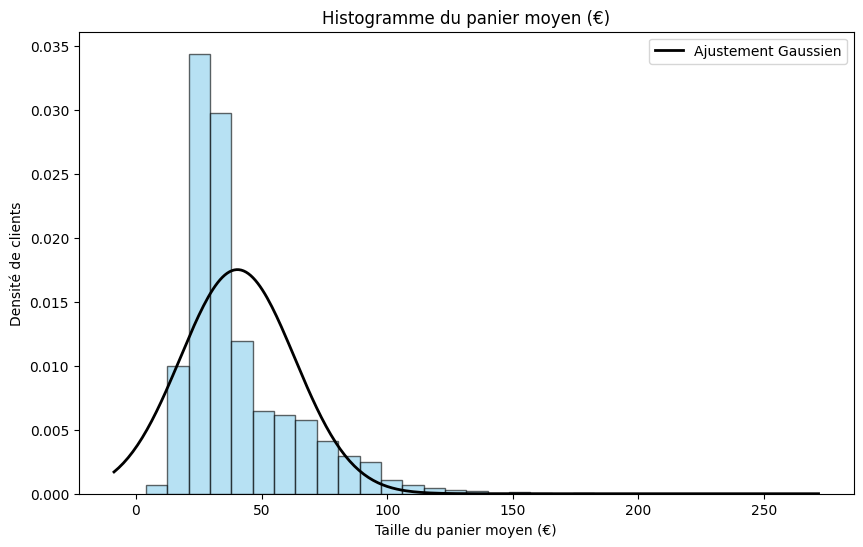

In [ ]:
# test distribution

# Extraire la colonne 'freq_achat'
panier = df_taille_panier['taille_panier_moyenne'].dropna()

# Calculer la moyenne et l'écart type
mean_panier = panier.mean()
std_panier = panier.std()

# Afficher les valeurs calculées
print(f"Moyenne du panier : {mean_panier}")
print(f"Écart type du panier moyen : {std_panier}")

# Tracer l'histogramme avec une courbe gaussienne
plt.figure(figsize=(10, 6))

# Histogramme

plt.hist(panier, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Ajustement gaussien
mu, std = norm.fit(panier)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 300)
p = norm.pdf(x, mu, std)

# Tracer la courbe gaussienne
plt.plot(x, p, 'k', linewidth=2, label='Ajustement Gaussien')

# Ajouter les titres et légendes en français
plt.title('Histogramme du panier moyen (€)')
plt.xlabel('Taille du panier moyen (€)')
plt.ylabel('Densité de clients')
plt.legend()

# Afficher le graphique
plt.show()

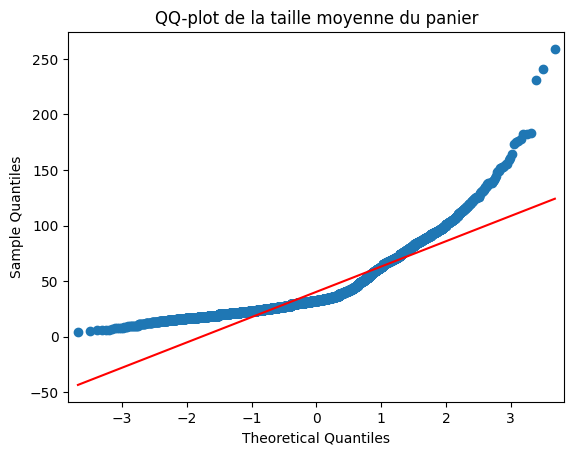

In [ ]:
#Faire graphique qqplot
sm.qqplot(df_taille_panier['taille_panier_moyenne'], line='s')
plt.title("QQ-plot de la taille moyenne du panier")
plt.show()
#Le QQ-plot de la taille moyenne du panier met en évidence une forte asymétrie à droite

Coefficient de corrélation de Spearman: -0.7003093738474152
Valeur p: 0.0


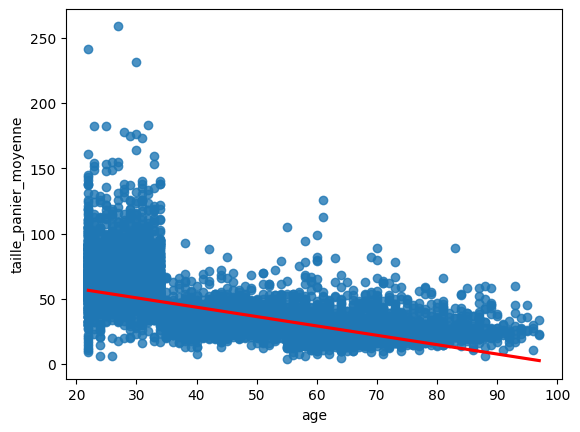

In [ ]:
# test de Spearman

# 1) Sélection colonnes
test_correlation = df_taille_panier[['age', 'taille_panier_moyenne']].dropna()

# 2) Visualisation correcte
sns.regplot(data=test_correlation,x='age',y='taille_panier_moyenne',robust=True,line_kws=dict(color="r"))

# 3) Pearson valide
correlation, p_value = spearmanr(test_correlation['age'], test_correlation['taille_panier_moyenne'])

print(f"Coefficient de corrélation de Spearman: {correlation}")
print(f"Valeur p: {p_value}")

# Il existe une corrélation négative forte et statistiquement significative entre l’âge et le prix du panier moyen (r ≈ -0,70 ; p < 0,05).

### Etape 3.5 - Corrélation entre l'âge du client et la catégorie de livre acheté

In [ ]:
# 1) Nombre d’achats par client et par catégorie
tmp = (df_clean.groupby(['client_id', 'categ']).size().reset_index(name='nb_achats'))

# 2) Garder la catégorie la plus achetée par client
idx = tmp.groupby('client_id')['nb_achats'].idxmax() #idx renvoie l'index de position de la valeur max de nb_achats par exemple pour le premier client c'est 0 car c'est la catégorie 0 qui contient le plus d'achat
df_client_cat = tmp.loc[idx].copy()# on crée un dataframe contenant pour chaque client la catégorie qui correspond au maximum du nb d'achat

# 3) Ajouter l’âge de chaque client
ages = df_clean.groupby('client_id', as_index=False).agg({'age': 'first'})
df_client_cat = df_client_cat.merge(ages, on='client_id')
display(df_client_cat)

,client_id,categ,nb_achats,age
0,c_1,0,30,71
1,c_10,1,34,70
2,c_100,1,5,34
3,c_1000,1,83,60
4,c_1001,0,70,44
...,...,...,...,...
8591,c_995,0,11,71
8592,c_996,1,56,56
8593,c_997,0,23,32
8594,c_998,2,28,25


In [ ]:
#H₀ (hypothèse nulle) : les variances d’âge sont égales entre les catégories.
#H₁ (hypothèse alternative) : au moins une catégorie a une variance différente.

# Test de Levene pour valider la condition sur la variance des groupes
stat, p = levene(
    df_client_cat[df_client_cat['categ'] == 0]['age'],
    df_client_cat[df_client_cat['categ'] == 1]['age'],
    df_client_cat[df_client_cat['categ'] == 2]['age']
)

print(f"Statistique de Levene : {round(stat,2)}")
if p > 0.05:
    print("p-value :", p)
    print("On ne peut pas rejeter H0")
else:
    print("p-value :", p)
    print("On rejette H0")


Statistique de Levene : 707.95
p-value : 2.4719568325291166e-285
On rejette H0


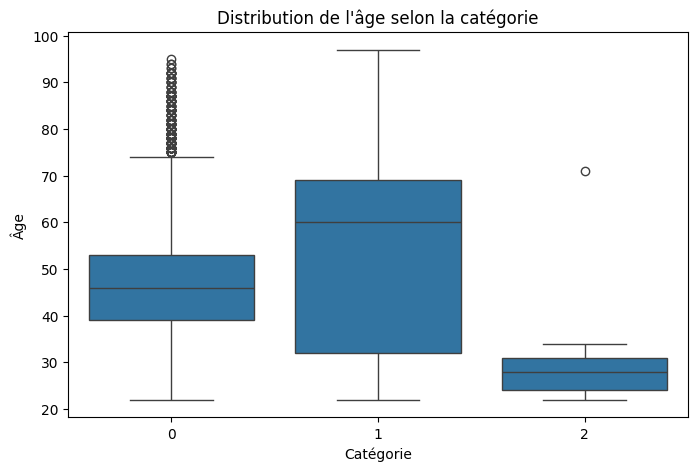

Statistique H (Kruskal-Wallis) : 2003.668
p-value : 0
On rejette H0
Au moins une catégorie a une distribution d'âge différente.


In [ ]:
# Préparer les groupes
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_client_cat, x='categ', y='age')

plt.xlabel("Catégorie")
plt.ylabel("Âge")
plt.title("Distribution de l'âge selon la catégorie")

plt.show()

#test de Kruskal-Wallis
groups = [
    df_client_cat.loc[df_client_cat['categ'] == c, 'age'].dropna()
    for c in sorted(df_client_cat['categ'].unique())
]

H, p = kruskal(*groups)

print(f"Statistique H (Kruskal-Wallis) : {H:.3f}")
print(f"p-value : {p:.3g}")

if p < 0.05:
    print("On rejette H0")
    print("Au moins une catégorie a une distribution d'âge différente.")
else:
    print("On ne peut pas rejeter H0")
    print("Pas de différence détectée entre les catégories.")

#l’âge varie fortement selon la catégorie comme on le voir avec la statistique H

In [ ]:
#quelle catégorie via test de Mann-Whitney U
categories = sorted(df_client_cat['categ'].unique())

results = []

for c1, c2 in itertools.combinations(categories, 2):
    group1 = df_client_cat.loc[df_client_cat['categ'] == c1, 'age'].dropna()
    group2 = df_client_cat.loc[df_client_cat['categ'] == c2, 'age'].dropna()

    U, p = mannwhitneyu(group1, group2, alternative='two-sided')

    results.append({
        'categorie_1': c1,
        'categorie_2': c2,
        'U_stat': U,
        'p_value': p
    })


df_posthoc = pd.DataFrame(results)

# Correction de Bonferroni
alpha = 0.05
df_posthoc['p_bonferroni'] = df_posthoc['p_value'] * len(df_posthoc)
df_posthoc['significatif'] = df_posthoc['p_bonferroni'] < alpha

display(df_posthoc)

,categorie_1,categorie_2,U_stat,p_value,p_bonferroni,significatif
0,0,1,5076560.5,2.434768e-86,7.304304e-86,True
1,0,2,4314541.5,0.000000e+00,0.000000e+00,True
2,1,2,2470253.0,1.006224e-230,3.018671e-230,True
